### Zero forcing set and Zero forcing cover

In graph theory, a **zero forcing set** of a graph `G` is a subset of vertices `Z` such that if you start with all vertices in `Z` colored blue and all other vertices colored white, you can eventually color the entire graph blue by repeatedly applying the following rule:

*   **Coloring Rule**: If a blue vertex `u` has exactly one white neighbor `v`, then `u` forces `v` to become blue.

The minimum size of a zero forcing set for a graph `G` is called the **zero forcing number** of `G`, often denoted `Z(G)`. Zero forcing sets are related to various topics in mathematics, including minimum rank problems, quantum information theory, and network control.

In [1]:
# Install networkx for graph visualization
!pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 250.8 kB/s eta 0:00:07
   ---------- ----------------------------- 0.5/2.1 MB 250.8 kB/s eta 0:00:07
   ---------- ----------------------------- 0.5/2.1 MB 250.8 kB/s eta 0:00:07
   ---------- ----------------------------- 0.5/2.1 MB 250.8 kB/s eta 0:00:0


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Zero Forcing on Path Graphs \(P_n\)

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import time # For pausing visualization

In [7]:
# def create_path_graph(n):
#     """
#     Creates an adjacency list representation of a path graph with n vertices.
#     Vertices are numbered from 0 to n-1.
#     """
#     graph = {i: [] for i in range(n)}
#     for i in range(n):
#         if i > 0:
#             graph[i].append(i - 1)
#         if i < n - 1:
#             graph[i].append(i + 1)
#     return graph

# def simulate_zero_forcing(graph, initial_blue_nodes, visualize=True):
#     """
#     Simulates the zero-forcing process on a given graph.
#     Prints each forcing step and optionally visualizes the graph at each step.
#     Returns the final set of blue nodes.
#     """
#     num_vertices = len(graph)
#     blue_nodes = set(initial_blue_nodes)
#     white_nodes = set(range(num_vertices)) - blue_nodes

#     print(f"Initial Blue Nodes: {sorted(list(blue_nodes))}")
#     print(f"Initial White Nodes: {sorted(list(white_nodes))}")
#     print("----------------------------------------")

#     G = nx.Graph(graph) # Create a networkx graph for visualization
#     pos = nx.spring_layout(G) # Position nodes for visualization

#     def draw_graph(current_blue, current_white, step_label="Initial State"):
#         if not visualize: return
#         plt.figure(figsize=(8, 6))
#         node_colors = ['blue' if node in current_blue else 'white' for node in G.nodes()]
#         node_edgecolors = ['black' if node in current_blue else 'gray' for node in G.nodes()]
#         nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors=node_edgecolors, linewidths=1.5)
#         nx.draw_networkx_edges(G, pos, edge_color='gray')
#         nx.draw_networkx_labels(G, pos, font_color='black', font_size=10)
#         plt.title(f"Zero-Forcing Simulation - {step_label}")
#         plt.axis('off')
#         plt.show()
#         time.sleep(1) # Pause for 1 second for better visualization

#     draw_graph(blue_nodes, white_nodes)

#     step = 0
#     while True:
#         forced_this_step = False
#         next_blue_nodes = set(blue_nodes) # Nodes that become blue in this step

#         for u in list(blue_nodes): # Iterate over current blue nodes
#             white_neighbors = [v for v in graph[u] if v in white_nodes]

#             if len(white_neighbors) == 1:
#                 v_to_force = white_neighbors[0]
#                 if v_to_force in white_nodes: # Ensure it hasn't been forced by another node in the same step
#                     step += 1
#                     print(f"Step {step}: Blue node {u} forces white neighbor {v_to_force} to become blue.")
#                     next_blue_nodes.add(v_to_force)
#                     white_nodes.discard(v_to_force)
#                     forced_this_step = True
#                     # Draw graph after each force
#                     draw_graph(next_blue_nodes, white_nodes, f"Step {step}: {u} forces {v_to_force}")

#         blue_nodes = next_blue_nodes

#         if not forced_this_step:
#             break

#     print("----------------------------------------")
#     print(f"Final Blue Nodes: {sorted(list(blue_nodes))}")
#     print(f"Final White Nodes: {sorted(list(white_nodes))}")
#     if not white_nodes:
#         print("All vertices have been colored blue!")
#     else:
#         print("No more forcing is possible. Some vertices remain white.")
#     draw_graph(blue_nodes, white_nodes, "Final State")
#     return blue_nodes

In [8]:
# try:
#     num_nodes_str = input("Enter the number of vertices for the path graph (e.g., 5): ")
#     num_nodes = int(num_nodes_str)

#     if num_nodes <= 1:
#         print("A path graph must have at least 2 vertices for interesting forcing.")
#     else:
#         path_graph = create_path_graph(num_nodes)
#         print(f"Path graph with {num_nodes} vertices created: {path_graph}")

#         initial_blue_input = input("Enter initial blue nodes (comma-separated, e.g., 0,2): ")
#         initial_blue_nodes = []
#         if initial_blue_input.strip():
#             initial_blue_nodes = [int(x.strip()) for x in initial_blue_input.split(',')]
#             # Validate input nodes are within graph range
#             for node in initial_blue_nodes:
#                 if not (0 <= node < num_nodes):
#                     raise ValueError(f"Node {node} is out of bounds for a graph with {num_nodes} vertices (0 to {num_nodes-1}).")

#         print("\n--- Simulating Zero-Forcing ---")
#         # Call simulate_zero_forcing with visualization enabled
#         simulate_zero_forcing(path_graph, initial_blue_nodes, visualize=True)

# except ValueError as e:
#     print(f"Invalid input: {e}. Please enter valid numbers and comma-separated integers.")
# except Exception as e:
#     print(f"An unexpected error occurred: {e}")

### Zero Forcing Cover (ZFC)

Let \( G \) be a graph. A set \( F \subseteq V(G) \) is called a **zero forcing cover** of \( G \) if for every subset  
\( F' \subset F \) with  
\[
|F'| = |F| - 1,
\]
the set \( F' \) is a zero forcing set of \( G \).

In other words, removing any single vertex from \( F \) still leaves a zero forcing set.

The **zero forcing cover number**, denoted by \( ZFC(G) \), is the minimum cardinality of such a set \( F \).

In [9]:
# def create_path_graph(n):
#     """
#     Creates an adjacency list representation of a path graph with n vertices.
#     Vertices are numbered from 0 to n-1.
#     """
#     graph = {i: [] for i in range(n)}
#     for i in range(n):
#         if i > 0:
#             graph[i].append(i - 1)
#         if i < n - 1:
#             graph[i].append(i + 1)
#     return graph

# def simulate_zero_forcing(graph, initial_blue_nodes, visualize=True):
#     """
#     Simulates the zero-forcing process on a given graph.
#     Prints each forcing step and optionally visualizes the graph at each step.
#     Returns the final set of blue nodes.
#     """
#     num_vertices = len(graph)
#     blue_nodes = set(initial_blue_nodes)
#     white_nodes = set(range(num_vertices)) - blue_nodes

#     print(f"Initial Blue Nodes: {sorted(list(blue_nodes))}")
#     print(f"Initial White Nodes: {sorted(list(white_nodes))}")
#     print("----------------------------------------")

#     G = nx.Graph(graph) # Create a networkx graph for visualization
#     pos = nx.spring_layout(G) # Position nodes for visualization

#     def draw_graph(current_blue, current_white, step_label="Initial State"):
#         if not visualize: return
#         plt.figure(figsize=(8, 6))
#         node_colors = ['blue' if node in current_blue else 'white' for node in G.nodes()]
#         node_edgecolors = ['black' if node in current_blue else 'gray' for node in G.nodes()]
#         nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors=node_edgecolors, linewidths=1.5)
#         nx.draw_networkx_edges(G, pos, edge_color='gray')
#         nx.draw_networkx_labels(G, pos, font_color='black', font_size=10)
#         plt.title(f"Zero-Forcing Simulation - {step_label}")
#         plt.axis('off')
#         plt.show()
#         time.sleep(1) # Pause for 1 second for better visualization

#     draw_graph(blue_nodes, white_nodes)

#     step = 0
#     while True:
#         forced_this_step = False
#         next_blue_nodes = set(blue_nodes) # Nodes that become blue in this step

#         for u in list(blue_nodes): # Iterate over current blue nodes
#             white_neighbors = [v for v in graph[u] if v in white_nodes]

#             if len(white_neighbors) == 1:
#                 v_to_force = white_neighbors[0]
#                 if v_to_force in white_nodes: # Ensure it hasn't been forced by another node in the same step
#                     step += 1
#                     print(f"Step {step}: Blue node {u} forces white neighbor {v_to_force} to become blue.")
#                     next_blue_nodes.add(v_to_force)
#                     white_nodes.discard(v_to_force)
#                     forced_this_step = True
#                     # Draw graph after each force
#                     draw_graph(next_blue_nodes, white_nodes, f"Step {step}: {u} forces {v_to_force}")

#         blue_nodes = next_blue_nodes

#         if not forced_this_step:
#             break

#     print("----------------------------------------")
#     print(f"Final Blue Nodes: {sorted(list(blue_nodes))}")
#     print(f"Final White Nodes: {sorted(list(white_nodes))}")
#     if not white_nodes:
#         print("All vertices have been colored blue!")
#     else:
#         print("No more forcing is possible. Some vertices remain white.")
#     draw_graph(blue_nodes, white_nodes, "Final State")
#     return blue_nodes

# def is_zero_forcing_set(graph, initial_blue_nodes):
#     """
#     Checks if a given set of initial_blue_nodes is a zero-forcing set for the graph.
#     Returns True if all vertices become blue, False otherwise.
#     """
#     num_vertices = len(graph)
#     if num_vertices == 0:
#         return True # An empty graph is trivially 'forced' by any set, including empty

#     blue_nodes = set(initial_blue_nodes)
#     if not blue_nodes and num_vertices > 0: # An empty set cannot force a non-empty graph
#         return False

#     white_nodes = set(range(num_vertices)) - blue_nodes

#     if not white_nodes: # All nodes already blue
#         return True

#     while True:
#         forced_this_step = False
#         next_blue_nodes = set(blue_nodes)

#         # Iterate over current blue nodes to find forcing opportunities
#         for u in list(blue_nodes): # Convert to list to iterate over a copy, allowing modification of blue_nodes inside
#             white_neighbors = [v for v in graph[u] if v in white_nodes]

#             if len(white_neighbors) == 1:
#                 v_to_force = white_neighbors[0]
#                 if v_to_force in white_nodes: # Check if still white (not forced by another node this step)
#                     next_blue_nodes.add(v_to_force)
#                     white_nodes.discard(v_to_force)
#                     forced_this_step = True
        
#         blue_nodes = next_blue_nodes

#         if len(blue_nodes) == num_vertices:
#             return True # All nodes are now blue

#         # If no new nodes were forced and not all nodes are blue, then it's not a ZFS
#         if not forced_this_step:
#             return False

# def find_all_zero_forcing_sets(graph):
#     """
#     Finds all zero forcing set(s) for a given graph, grouped by size.
#     Returns the minimum ZFS number, a list of all ZFS sets of that size, and a dictionary of all ZFS sets by size.
#     """
#     num_vertices = len(graph)
#     all_vertices = set(range(num_vertices))
#     all_zfs_by_size = {} # To store {size: [list of ZFS sets]}
#     min_zfs_number = -1
#     min_zfs_sets = []

#     print(f"\nFinding all Zero Forcing Sets for a graph with {num_vertices} vertices...")

#     for k in range(1, num_vertices + 1):
#         current_k_zfs = []
#         for combo in itertools.combinations(all_vertices, k):
#             if is_zero_forcing_set(graph, list(combo)):
#                 current_k_zfs.append(sorted(list(combo)))
#         if current_k_zfs:
#             all_zfs_by_size[k] = current_k_zfs
#             if min_zfs_number == -1: # First time we find a ZFS
#                 min_zfs_number = k
#                 min_zfs_sets = current_k_zfs

#     return min_zfs_number, min_zfs_sets, all_zfs_by_size

# def find_all_zero_forcing_covers_for_path_graph(n):
#     """
#     Finds all zero forcing cover sets for a path graph with n vertices, grouped by size.
#     Returns the minimum ZFC number, a list of all ZFC sets of that size, and a dictionary of all ZFC sets by size.
#     """
#     if n <= 0:
#         return 0, [], {}

#     path_graph = create_path_graph(n)
#     all_vertices = set(range(n))
#     all_zfc_by_size = {} # To store {size: [list of ZFC sets]}
#     min_zfc_number = -1
#     min_zfc_sets = []

#     print(f"\nFinding all Zero Forcing Covers for a Path Graph with {n} vertices...")

#     for k in range(1, n + 1):
#         current_k_zfc = []
#         for F_candidate_tuple in itertools.combinations(all_vertices, k):
#             F_candidate = set(F_candidate_tuple)
            
#             is_zfc_candidate = True

#             if k == 1 and n > 0: # An empty set is not generally a ZFS for a non-empty graph
#                 is_zfc_candidate = False
#             else: # For k > 1 or n == 0 (already handled)
#                 for removed_node in F_candidate:
#                     F_prime = F_candidate - {removed_node}
#                     if not is_zero_forcing_set(path_graph, list(F_prime)): # is_zero_forcing_set expects list
#                         is_zfc_candidate = False
#                         break # F_candidate is not a ZFC, move to next F_candidate

#             if is_zfc_candidate:
#                 current_k_zfc.append(sorted(list(F_candidate)))
        
#         if current_k_zfc:
#             all_zfc_by_size[k] = current_k_zfc
#             if min_zfc_number == -1: # First time we find a ZFC
#                 min_zfc_number = k
#                 min_zfc_sets = current_k_zfc

#     return min_zfc_number, min_zfc_sets, all_zfc_by_size

# # --- Combined Interactive Demonstration ---
# try:
#     num_nodes_combined_str = input("Enter the number of vertices for the path graph (e.g., 5) for the combined ZFS/ZFC demonstration: ")
#     num_nodes_combined = int(num_nodes_combined_str)

#     if num_nodes_combined <= 0:
#         print("Number of vertices must be positive.")
#     else:
#         print(f"\n--- Step 1: Finding Zero Forcing Sets and Covers for P{num_nodes_combined} ---")
#         path_graph_combined = create_path_graph(num_nodes_combined)

#         # Find and print all Zero Forcing Sets
#         min_zfs_number, min_zfs_sets, all_zfs_by_size = find_all_zero_forcing_sets(path_graph_combined)
#         if min_zfs_number != -1:
#             print(f"\nMinimum Zero Forcing Number (Z({num_nodes_combined})): {min_zfs_number}")
#             print(f"Corresponding Minimum ZFS Sets: {min_zfs_sets}")
#             if len(all_zfs_by_size) > 0:
#                 print("\nAll Zero Forcing Sets found, grouped by size:")
#                 for size, zfs_list in sorted(all_zfs_by_size.items()):
#                     print(f"  Size {size}: {zfs_list}")
#         else:
#             print(f"\nCould not find any Zero Forcing Set for a path graph with {num_nodes_combined} vertices.")

#         # Find and print all Zero Forcing Covers
#         min_zfc_number, min_zfc_sets, all_zfc_by_size = find_all_zero_forcing_covers_for_path_graph(num_nodes_combined)
#         if min_zfc_number != -1:
#             print(f"\nMinimum Zero Forcing Cover Number (ZFC({num_nodes_combined})): {min_zfc_number}")
#             print(f"Corresponding Minimum ZFC Sets: {min_zfc_sets}")
#             if len(all_zfc_by_size) > 0:
#                 print("\nAll Zero Forcing Cover Sets found, grouped by size:")
#                 for size, zfc_list in sorted(all_zfc_by_size.items()):
#                     print(f"  Size {size}: {zfc_list}")
#         else:
#             print(f"\nCould not find any Zero Forcing Cover for a path graph with {num_nodes_combined} vertices.")


#         print(f"\n--- Step 2: Demonstrating ZFC properties for P{num_nodes_combined} (Minimum ZFC Sets only) ---")
#         if min_zfc_sets:
#             for i, F_candidate_list in enumerate(min_zfc_sets):
#                 F_candidate = set(F_candidate_list)
#                 print(f"\nDemonstrating Minimum ZFC set {i+1}: {sorted(list(F_candidate))}")

#                 # List the ZFS subsets (F_prime) that will be demonstrated for this ZFC set
#                 if len(F_candidate) > 0:
#                     print(f"  The ZFS subsets (F') derived from this ZFC set are:")
#                     for removed_node_temp in F_candidate:
#                         F_prime_temp = F_candidate - {removed_node_temp}
#                         print(f"    - {sorted(list(F_prime_temp))} (by removing {removed_node_temp})")
#                 else:
#                     print("  This ZFC set is empty, so no ZFS subsets (F') can be derived.")

#                 # First, simulate the full ZFC set to show it's a ZFS
#                 print(f"\nSimulating the full ZFC set: {sorted(list(F_candidate))}")
#                 simulate_zero_forcing(path_graph_combined, list(F_candidate), visualize=True)
#                 print("\n----------------------------------------")
#                 print("Full ZFC set simulation complete.")
#                 print("----------------------------------------")

#                 # Then, iterate through F_prime (ZFC minus one element)
#                 if len(F_candidate) > 0:
#                     for removed_node in F_candidate:
#                         F_prime = F_candidate - {removed_node}
#                         print(f"\nSimulating F_prime: {sorted(list(F_prime))} (original ZFC set minus {removed_node}) - Expected to be a ZFS.")
#                         if is_zero_forcing_set(path_graph_combined, list(F_prime)):
#                             print(f"This F_prime is indeed a Zero Forcing Set. Simulating...")
#                             simulate_zero_forcing(path_graph_combined, list(F_prime), visualize=True)
#                             print("----------------------------------------")
#                             print("F_prime simulation complete.")
#                             print("----------------------------------------")
#                         else:
#                             print(f"ERROR: F_prime {sorted(list(F_prime))} was expected to be a ZFS but is not. This should not happen if {sorted(list(F_candidate))} is a true ZFC.")
#                 else:
#                     print("Skipping F_prime demonstrations as the ZFC set is empty.")
#         else:
#             print("No minimum ZFC sets found to demonstrate.")

# except ValueError as e:
#     print(f"Invalid input: {e}. Please enter a valid positive integer.")
# except Exception as e:
#     print(f"An unexpected error occurred: {e}")


Finding ZFS for P3...

Minimum ZFS = 1
Minimum ZFS sets: [[0], [2]]

All ZFS by size:
Size 1: [[0], [2]]
Size 2: [[0, 1], [0, 2], [1, 2]]
Size 3: [[0, 1, 2]]

Finding ZFC for P3...

Minimum ZFC = 2
Minimum ZFC sets: [[0, 2]]

All ZFC by size:
Size 2: [[0, 2]]
Size 3: [[0, 1, 2]]

--- Simulation using one minimum ZFS ---
Initial Blue Nodes: [0]
Initial White Nodes: [1, 2]
----------------------------------------


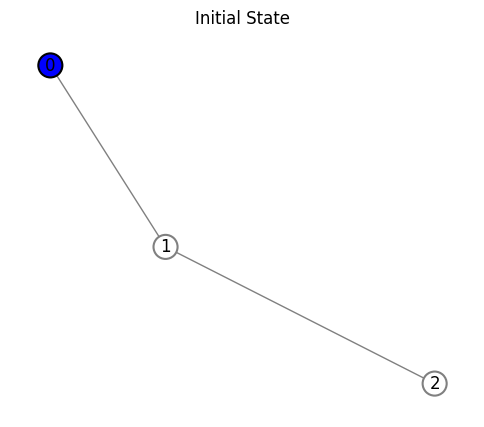

Step 1: 0 forces 1


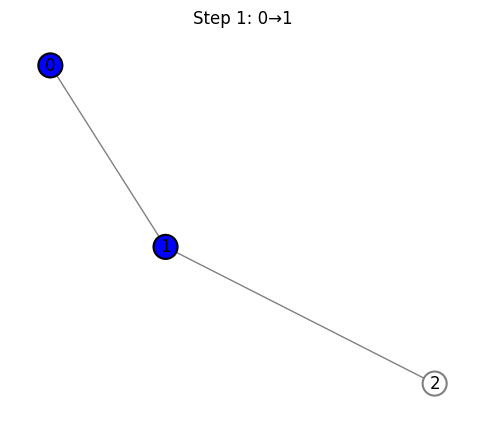

Step 2: 1 forces 2


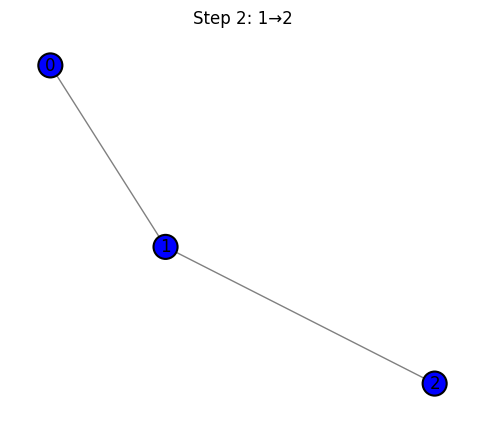

----------------------------------------
Final Blue Nodes: [0, 1, 2]
Final White Nodes: []
All vertices became blue!


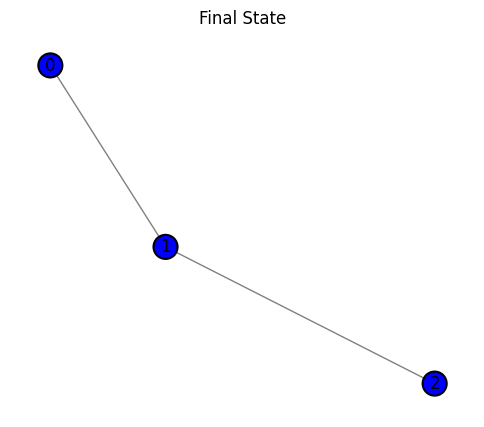

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import itertools

# --------- PATH GRAPH ---------
def create_path_graph(n):
    """
    Creates an adjacency list representation of a path graph with n vertices.
    """
    graph = {i: [] for i in range(n)}
    for i in range(n):
        if i > 0:
            graph[i].append(i - 1)
        if i < n - 1:
            graph[i].append(i + 1)
    return graph


# --------- ZERO FORCING SIMULATION ---------
def simulate_zero_forcing(graph, initial_blue_nodes, visualize=True):
    num_vertices = len(graph)
    blue_nodes = set(initial_blue_nodes)
    white_nodes = set(range(num_vertices)) - blue_nodes

    print(f"Initial Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Initial White Nodes: {sorted(list(white_nodes))}")
    print("----------------------------------------")

    G = nx.Graph(graph)
    pos = nx.spring_layout(G)

    def draw_graph(current_blue, current_white, step_label="State"):
        if not visualize:
            return
        plt.figure(figsize=(6, 5))
        node_colors = ['blue' if node in current_blue else 'white' for node in G.nodes()]
        node_edgecolors = ['black' if node in current_blue else 'gray' for node in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               edgecolors=node_edgecolors, linewidths=1.5)
        nx.draw_networkx_edges(G, pos, edge_color='gray')
        nx.draw_networkx_labels(G, pos)
        plt.title(f"{step_label}")
        plt.axis('off')
        plt.show()
        time.sleep(1)

    draw_graph(blue_nodes, white_nodes, "Initial State")

    step = 0
    while True:
        forced = False
        next_blue = set(blue_nodes)

        for u in list(blue_nodes):
            white_neighbors = [v for v in graph[u] if v in white_nodes]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                if v in white_nodes:
                    step += 1
                    print(f"Step {step}: {u} forces {v}")
                    next_blue.add(v)
                    white_nodes.remove(v)
                    forced = True
                    draw_graph(next_blue, white_nodes, f"Step {step}: {u}→{v}")

        blue_nodes = next_blue

        if not forced:
            break

    print("----------------------------------------")
    print(f"Final Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Final White Nodes: {sorted(list(white_nodes))}")

    if not white_nodes:
        print("All vertices became blue!")
    else:
        print("Forcing stopped before completion.")

    draw_graph(blue_nodes, white_nodes, "Final State")
    return blue_nodes


# --------- CHECK ZFS ---------
def is_zero_forcing_set(graph, initial_blue_nodes):
    n = len(graph)
    blue = set(initial_blue_nodes)
    white = set(range(n)) - blue

    if not blue:
        return False

    while True:
        changed = False
        new_blue = set(blue)

        for u in list(blue):
            white_neighbors = [v for v in graph[u] if v in white]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                new_blue.add(v)
                white.remove(v)
                changed = True

        blue = new_blue

        if len(blue) == n:
            return True
        if not changed:
            return False


# --------- FIND ALL ZFS ---------
def find_all_zero_forcing_sets(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfs = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFS for P{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            if is_zero_forcing_set(graph, combo):
                current.append(list(combo))

        if current:
            all_sets[k] = current
            if min_zfs == -1:
                min_zfs = k
                min_sets = current

    return min_zfs, min_sets, all_sets


# --------- FIND ZFC ---------
def find_all_zero_forcing_covers(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfc = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFC for P{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            F = set(combo)

            valid = True
            for removed in F:
                if not is_zero_forcing_set(graph, F - {removed}):
                    valid = False
                    break

            if valid:
                current.append(list(F))

        if current:
            all_sets[k] = current
            if min_zfc == -1:
                min_zfc = k
                min_sets = current

    return min_zfc, min_sets, all_sets


# --------- MAIN ---------
try:
    n = int(input("Enter number of vertices for Path Graph P_n: "))

    if n <= 0:
        print("Enter positive number.")
    else:
        G = create_path_graph(n)

        # ZFS
        min_zfs, min_sets, all_zfs = find_all_zero_forcing_sets(G)
        print(f"\nMinimum ZFS = {min_zfs}")
        print(f"Minimum ZFS sets: {min_sets}")

        print("\nAll ZFS by size:")
        for k, v in all_zfs.items():
            print(f"Size {k}: {v}")

        # ZFC
        min_zfc, min_sets_zfc, all_zfc = find_all_zero_forcing_covers(G)
        print(f"\nMinimum ZFC = {min_zfc}")
        print(f"Minimum ZFC sets: {min_sets_zfc}")

        print("\nAll ZFC by size:")
        for k, v in all_zfc.items():
            print(f"Size {k}: {v}")

        # Demonstration
        if min_sets:
            print("\n--- Simulation using one minimum ZFS ---")
            simulate_zero_forcing(G, min_sets[0], visualize=True)

except Exception as e:
    print("Error:", e)

### Zero Forcing on Complete Graphs \(K_n\)


Finding ZFS for K5...

Minimum ZFS = 4
Minimum ZFS sets: [[0, 1, 2, 3], [0, 1, 2, 4], [0, 1, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4]]

All ZFS by size:
Size 4: [[0, 1, 2, 3], [0, 1, 2, 4], [0, 1, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4]]
Size 5: [[0, 1, 2, 3, 4]]

Finding ZFC for K5...

Minimum ZFC = 5
Minimum ZFC sets: [[0, 1, 2, 3, 4]]

All ZFC by size:
Size 5: [[0, 1, 2, 3, 4]]

--- Simulation using one minimum ZFS ---
Initial Blue Nodes: [0, 1, 2, 3]
Initial White Nodes: [4]
----------------------------------------


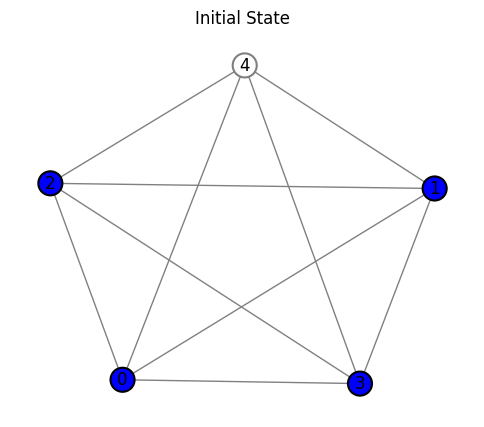

Step 1: 0 forces 4


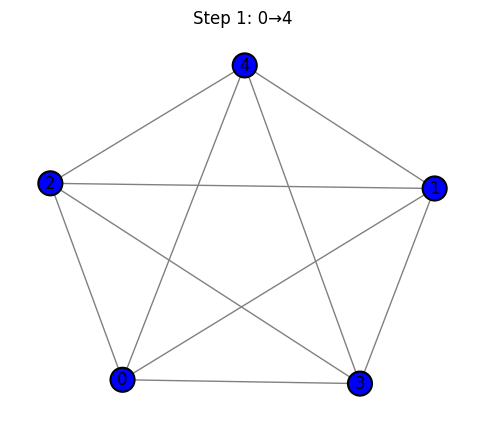

----------------------------------------
Final Blue Nodes: [0, 1, 2, 3, 4]
Final White Nodes: []
All vertices became blue!


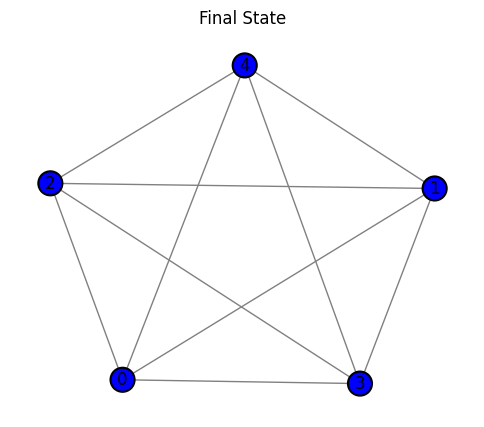

In [12]:

# --------- COMPLETE GRAPH ---------
def create_complete_graph(n):
    """
    Creates an adjacency list representation of a complete graph with n vertices.
    """
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            if i != j:
                graph[i].append(j)
    return graph


# --------- ZERO FORCING SIMULATION ---------
def simulate_zero_forcing(graph, initial_blue_nodes, visualize=True):
    num_vertices = len(graph)
    blue_nodes = set(initial_blue_nodes)
    white_nodes = set(range(num_vertices)) - blue_nodes

    print(f"Initial Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Initial White Nodes: {sorted(list(white_nodes))}")
    print("----------------------------------------")

    G = nx.Graph(graph)
    pos = nx.spring_layout(G)

    def draw_graph(current_blue, current_white, step_label="State"):
        if not visualize:
            return
        plt.figure(figsize=(6, 5))
        node_colors = ['blue' if node in current_blue else 'white' for node in G.nodes()]
        node_edgecolors = ['black' if node in current_blue else 'gray' for node in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               edgecolors=node_edgecolors, linewidths=1.5)
        nx.draw_networkx_edges(G, pos, edge_color='gray')
        nx.draw_networkx_labels(G, pos)
        plt.title(f"{step_label}")
        plt.axis('off')
        plt.show()
        time.sleep(1)

    draw_graph(blue_nodes, white_nodes, "Initial State")

    step = 0
    while True:
        forced = False
        next_blue = set(blue_nodes)

        for u in list(blue_nodes):
            white_neighbors = [v for v in graph[u] if v in white_nodes]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                if v in white_nodes:
                    step += 1
                    print(f"Step {step}: {u} forces {v}")
                    next_blue.add(v)
                    white_nodes.remove(v)
                    forced = True
                    draw_graph(next_blue, white_nodes, f"Step {step}: {u}→{v}")

        blue_nodes = next_blue

        if not forced:
            break

    print("----------------------------------------")
    print(f"Final Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Final White Nodes: {sorted(list(white_nodes))}")

    if not white_nodes:
        print("All vertices became blue!")
    else:
        print("Forcing stopped before completion.")

    draw_graph(blue_nodes, white_nodes, "Final State")
    return blue_nodes


# --------- CHECK ZFS ---------
def is_zero_forcing_set(graph, initial_blue_nodes):
    n = len(graph)
    blue = set(initial_blue_nodes)
    white = set(range(n)) - blue

    if not blue:
        return False

    while True:
        changed = False
        new_blue = set(blue)

        for u in list(blue):
            white_neighbors = [v for v in graph[u] if v in white]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                new_blue.add(v)
                white.remove(v)
                changed = True

        blue = new_blue

        if len(blue) == n:
            return True
        if not changed:
            return False


# --------- FIND ALL ZFS ---------
def find_all_zero_forcing_sets(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfs = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFS for K{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            if is_zero_forcing_set(graph, combo):
                current.append(list(combo))

        if current:
            all_sets[k] = current
            if min_zfs == -1:
                min_zfs = k
                min_sets = current

    return min_zfs, min_sets, all_sets


# --------- FIND ZFC ---------
def find_all_zero_forcing_covers(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfc = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFC for K{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            F = set(combo)

            valid = True
            for removed in F:
                if not is_zero_forcing_set(graph, F - {removed}):
                    valid = False
                    break

            if valid:
                current.append(list(F))

        if current:
            all_sets[k] = current
            if min_zfc == -1:
                min_zfc = k
                min_sets = current

    return min_zfc, min_sets, all_sets


# --------- MAIN ---------
try:
    n = int(input("Enter number of vertices for Complete Graph K_n: "))

    if n <= 0:
        print("Enter positive number.")
    else:
        G = create_complete_graph(n)

        # ZFS
        min_zfs, min_sets, all_zfs = find_all_zero_forcing_sets(G)
        print(f"\nMinimum ZFS = {min_zfs}")
        print(f"Minimum ZFS sets: {min_sets}")

        print("\nAll ZFS by size:")
        for k, v in all_zfs.items():
            print(f"Size {k}: {v}")

        # ZFC
        min_zfc, min_sets_zfc, all_zfc = find_all_zero_forcing_covers(G)
        print(f"\nMinimum ZFC = {min_zfc}")
        print(f"Minimum ZFC sets: {min_sets_zfc}")

        print("\nAll ZFC by size:")
        for k, v in all_zfc.items():
            print(f"Size {k}: {v}")

        # Demonstration
        if min_sets:
            print("\n--- Simulation using one minimum ZFS ---")
            simulate_zero_forcing(G, min_sets[0], visualize=True)

except Exception as e:
    print("Error:", e)

### Zero Forcing on Complete Graphs (C_n)


Finding ZFS for C4...

Minimum ZFS = 2
Minimum ZFS sets: [[0, 1], [0, 3], [1, 2], [2, 3]]

All ZFS by size:
Size 2: [[0, 1], [0, 3], [1, 2], [2, 3]]
Size 3: [[0, 1, 2], [0, 1, 3], [0, 2, 3], [1, 2, 3]]
Size 4: [[0, 1, 2, 3]]

Finding ZFC for C4...

Minimum ZFC = 4
Minimum ZFC sets: [[0, 1, 2, 3]]

All ZFC by size:
Size 4: [[0, 1, 2, 3]]

--- Simulation using one minimum ZFS ---
Initial Blue Nodes: [0, 1]
Initial White Nodes: [2, 3]
----------------------------------------


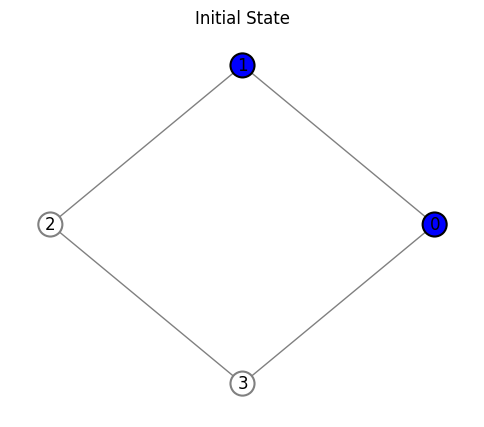

Step 1: 0 forces 3


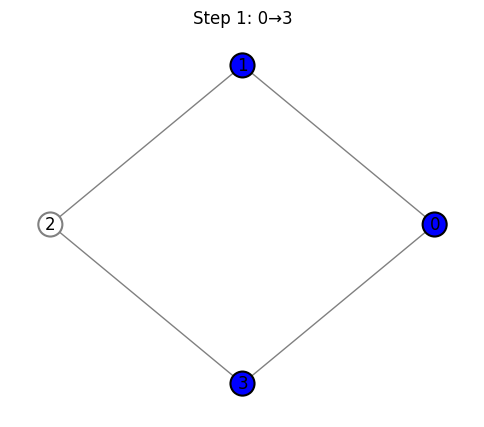

Step 2: 1 forces 2


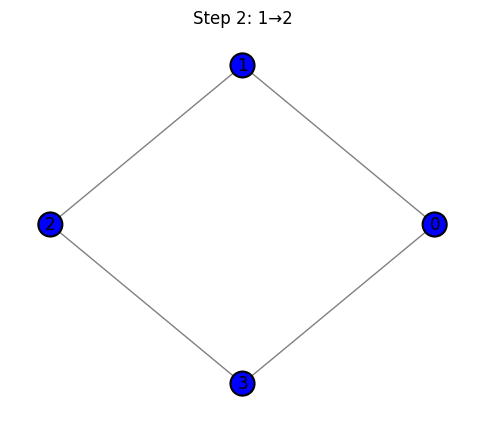

----------------------------------------
Final Blue Nodes: [0, 1, 2, 3]
Final White Nodes: []
All vertices became blue!


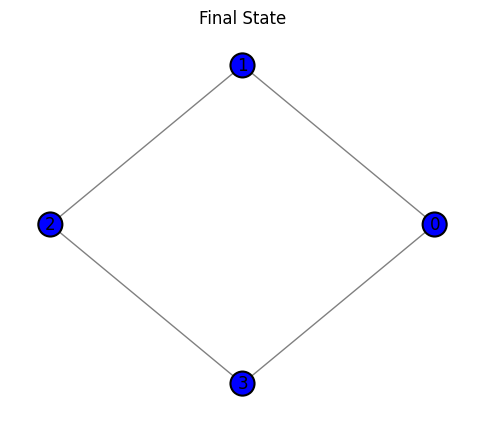

In [13]:
# --------- CYCLE GRAPH ---------
def create_cycle_graph(n):
    """
    Creates an adjacency list representation of a cycle graph with n vertices.
    """
    graph = {i: [] for i in range(n)}
    for i in range(n):
        graph[i].append((i - 1) % n)  # previous vertex
        graph[i].append((i + 1) % n)  # next vertex
    return graph


# --------- ZERO FORCING SIMULATION ---------
def simulate_zero_forcing(graph, initial_blue_nodes, visualize=True):
    num_vertices = len(graph)
    blue_nodes = set(initial_blue_nodes)
    white_nodes = set(range(num_vertices)) - blue_nodes

    print(f"Initial Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Initial White Nodes: {sorted(list(white_nodes))}")
    print("----------------------------------------")

    G = nx.Graph(graph)
    pos = nx.circular_layout(G)

    def draw_graph(current_blue, current_white, step_label="State"):
        if not visualize:
            return
        plt.figure(figsize=(6, 5))
        node_colors = ['blue' if node in current_blue else 'white' for node in G.nodes()]
        node_edgecolors = ['black' if node in current_blue else 'gray' for node in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               edgecolors=node_edgecolors, linewidths=1.5)
        nx.draw_networkx_edges(G, pos, edge_color='gray')
        nx.draw_networkx_labels(G, pos)
        plt.title(f"{step_label}")
        plt.axis('off')
        plt.show()
        time.sleep(1)

    draw_graph(blue_nodes, white_nodes, "Initial State")

    step = 0
    while True:
        forced = False
        next_blue = set(blue_nodes)

        for u in list(blue_nodes):
            white_neighbors = [v for v in graph[u] if v in white_nodes]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                if v in white_nodes:
                    step += 1
                    print(f"Step {step}: {u} forces {v}")
                    next_blue.add(v)
                    white_nodes.remove(v)
                    forced = True
                    draw_graph(next_blue, white_nodes, f"Step {step}: {u}→{v}")

        blue_nodes = next_blue

        if not forced:
            break

    print("----------------------------------------")
    print(f"Final Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Final White Nodes: {sorted(list(white_nodes))}")

    if not white_nodes:
        print("All vertices became blue!")
    else:
        print("Forcing stopped before completion.")

    draw_graph(blue_nodes, white_nodes, "Final State")
    return blue_nodes


# --------- CHECK ZFS ---------
def is_zero_forcing_set(graph, initial_blue_nodes):
    n = len(graph)
    blue = set(initial_blue_nodes)
    white = set(range(n)) - blue

    if not blue:
        return False

    while True:
        changed = False
        new_blue = set(blue)

        for u in list(blue):
            white_neighbors = [v for v in graph[u] if v in white]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                new_blue.add(v)
                white.remove(v)
                changed = True

        blue = new_blue

        if len(blue) == n:
            return True
        if not changed:
            return False


# --------- FIND ALL ZFS ---------
def find_all_zero_forcing_sets(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfs = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFS for C{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            if is_zero_forcing_set(graph, combo):
                current.append(list(combo))

        if current:
            all_sets[k] = current
            if min_zfs == -1:
                min_zfs = k
                min_sets = current

    return min_zfs, min_sets, all_sets


# --------- FIND ZFC ---------
def find_all_zero_forcing_covers(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfc = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFC for C{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            F = set(combo)

            valid = True
            for removed in F:
                if not is_zero_forcing_set(graph, F - {removed}):
                    valid = False
                    break

            if valid:
                current.append(list(F))

        if current:
            all_sets[k] = current
            if min_zfc == -1:
                min_zfc = k
                min_sets = current

    return min_zfc, min_sets, all_sets


# --------- MAIN ---------
try:
    n = int(input("Enter number of vertices for Cycle Graph C_n: "))

    if n <= 2:
        print("Cycle graph requires n ≥ 3.")
    else:
        G = create_cycle_graph(n)

        # ZFS
        min_zfs, min_sets, all_zfs = find_all_zero_forcing_sets(G)
        print(f"\nMinimum ZFS = {min_zfs}")
        print(f"Minimum ZFS sets: {min_sets}")

        print("\nAll ZFS by size:")
        for k, v in all_zfs.items():
            print(f"Size {k}: {v}")

        # ZFC
        min_zfc, min_sets_zfc, all_zfc = find_all_zero_forcing_covers(G)
        print(f"\nMinimum ZFC = {min_zfc}")
        print(f"Minimum ZFC sets: {min_sets_zfc}")

        print("\nAll ZFC by size:")
        for k, v in all_zfc.items():
            print(f"Size {k}: {v}")

        # Demonstration
        if min_sets:
            print("\n--- Simulation using one minimum ZFS ---")
            simulate_zero_forcing(G, min_sets[0], visualize=True)

except Exception as e:
    print("Error:", e)

### Zero Forcing on Complete Graphs (K_{1,n-1})


Finding ZFS for S5...

Minimum ZFS = 3
Minimum ZFS sets: [[1, 2, 3], [1, 2, 4], [1, 3, 4], [2, 3, 4]]

All ZFS by size:
Size 3: [[1, 2, 3], [1, 2, 4], [1, 3, 4], [2, 3, 4]]
Size 4: [[0, 1, 2, 3], [0, 1, 2, 4], [0, 1, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4]]
Size 5: [[0, 1, 2, 3, 4]]

Finding ZFC for S5...

Minimum ZFC = 4
Minimum ZFC sets: [[1, 2, 3, 4]]

All ZFC by size:
Size 4: [[1, 2, 3, 4]]
Size 5: [[0, 1, 2, 3, 4]]

--- Simulation using one minimum ZFS ---
Initial Blue Nodes: [1, 2, 3]
Initial White Nodes: [0, 4]
----------------------------------------


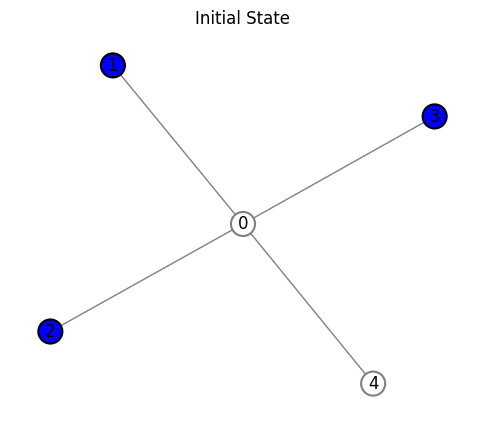

Step 1: 1 forces 0


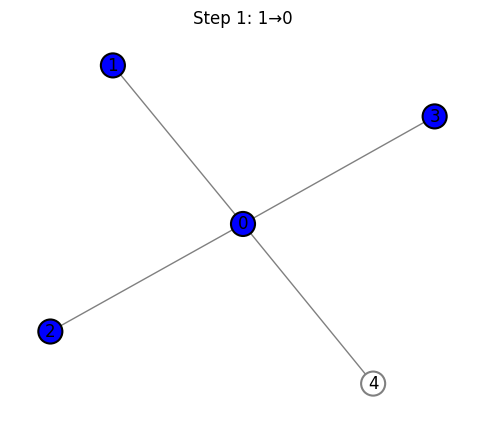

Step 2: 0 forces 4


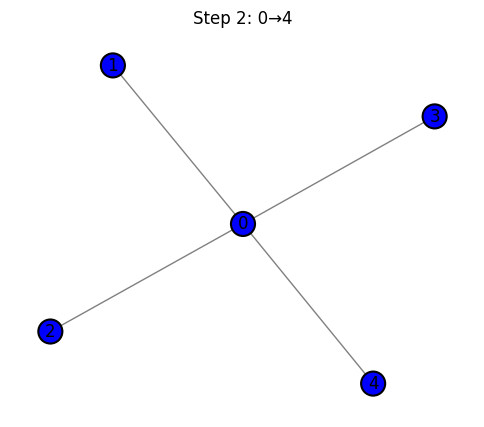

----------------------------------------
Final Blue Nodes: [0, 1, 2, 3, 4]
Final White Nodes: []
All vertices became blue!


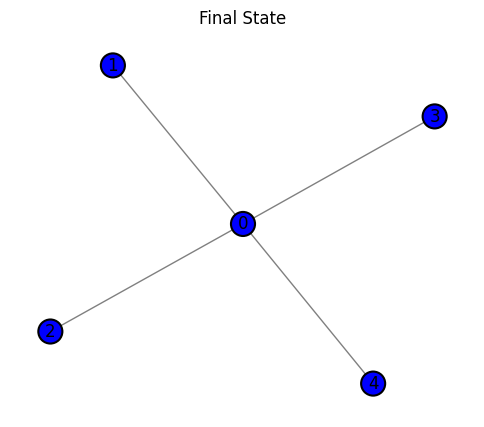

In [14]:

# --------- STAR GRAPH ---------
def create_star_graph(n):
    """
    Creates an adjacency list for star graph S_n (K_{1,n-1})
    Vertex 0 is the center.
    """
    graph = {i: [] for i in range(n)}

    for i in range(1, n):
        graph[0].append(i)   # center connected to all
        graph[i].append(0)   # leaves connected to center

    return graph


# --------- ZERO FORCING SIMULATION ---------
def simulate_zero_forcing(graph, initial_blue_nodes, visualize=True):
    num_vertices = len(graph)
    blue_nodes = set(initial_blue_nodes)
    white_nodes = set(range(num_vertices)) - blue_nodes

    print(f"Initial Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Initial White Nodes: {sorted(list(white_nodes))}")
    print("----------------------------------------")

    G = nx.Graph(graph)
    pos = nx.spring_layout(G)

    def draw_graph(current_blue, current_white, step_label="State"):
        if not visualize:
            return
        plt.figure(figsize=(6, 5))
        node_colors = ['blue' if node in current_blue else 'white' for node in G.nodes()]
        node_edgecolors = ['black' if node in current_blue else 'gray' for node in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               edgecolors=node_edgecolors, linewidths=1.5)
        nx.draw_networkx_edges(G, pos, edge_color='gray')
        nx.draw_networkx_labels(G, pos)
        plt.title(f"{step_label}")
        plt.axis('off')
        plt.show()
        time.sleep(1)

    draw_graph(blue_nodes, white_nodes, "Initial State")

    step = 0
    while True:
        forced = False
        next_blue = set(blue_nodes)

        for u in list(blue_nodes):
            white_neighbors = [v for v in graph[u] if v in white_nodes]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                if v in white_nodes:
                    step += 1
                    print(f"Step {step}: {u} forces {v}")
                    next_blue.add(v)
                    white_nodes.remove(v)
                    forced = True
                    draw_graph(next_blue, white_nodes, f"Step {step}: {u}→{v}")

        blue_nodes = next_blue

        if not forced:
            break

    print("----------------------------------------")
    print(f"Final Blue Nodes: {sorted(list(blue_nodes))}")
    print(f"Final White Nodes: {sorted(list(white_nodes))}")

    if not white_nodes:
        print("All vertices became blue!")
    else:
        print("Forcing stopped before completion.")

    draw_graph(blue_nodes, white_nodes, "Final State")
    return blue_nodes


# --------- CHECK ZFS ---------
def is_zero_forcing_set(graph, initial_blue_nodes):
    n = len(graph)
    blue = set(initial_blue_nodes)
    white = set(range(n)) - blue

    if not blue:
        return False

    while True:
        changed = False
        new_blue = set(blue)

        for u in list(blue):
            white_neighbors = [v for v in graph[u] if v in white]

            if len(white_neighbors) == 1:
                v = white_neighbors[0]
                new_blue.add(v)
                white.remove(v)
                changed = True

        blue = new_blue

        if len(blue) == n:
            return True
        if not changed:
            return False


# --------- FIND ALL ZFS ---------
def find_all_zero_forcing_sets(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfs = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFS for S{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            if is_zero_forcing_set(graph, combo):
                current.append(list(combo))

        if current:
            all_sets[k] = current
            if min_zfs == -1:
                min_zfs = k
                min_sets = current

    return min_zfs, min_sets, all_sets


# --------- FIND ZFC ---------
def find_all_zero_forcing_covers(graph):
    n = len(graph)
    vertices = set(range(n))

    min_zfc = -1
    min_sets = []
    all_sets = {}

    print(f"\nFinding ZFC for S{n}...")

    for k in range(1, n + 1):
        current = []
        for combo in itertools.combinations(vertices, k):
            F = set(combo)

            valid = True
            for removed in F:
                if not is_zero_forcing_set(graph, F - {removed}):
                    valid = False
                    break

            if valid:
                current.append(list(F))

        if current:
            all_sets[k] = current
            if min_zfc == -1:
                min_zfc = k
                min_sets = current

    return min_zfc, min_sets, all_sets


# --------- MAIN ---------
try:
    n = int(input("Enter number of vertices for Star Graph S_n: "))

    if n <= 1:
        print("Star graph requires n ≥ 2.")
    else:
        G = create_star_graph(n)

        # ZFS
        min_zfs, min_sets, all_zfs = find_all_zero_forcing_sets(G)
        print(f"\nMinimum ZFS = {min_zfs}")
        print(f"Minimum ZFS sets: {min_sets}")

        print("\nAll ZFS by size:")
        for k, v in all_zfs.items():
            print(f"Size {k}: {v}")

        # ZFC
        min_zfc, min_sets_zfc, all_zfc = find_all_zero_forcing_covers(G)
        print(f"\nMinimum ZFC = {min_zfc}")
        print(f"Minimum ZFC sets: {min_sets_zfc}")

        print("\nAll ZFC by size:")
        for k, v in all_zfc.items():
            print(f"Size {k}: {v}")

        # Simulation
        if min_sets:
            print("\n--- Simulation using one minimum ZFS ---")
            simulate_zero_forcing(G, min_sets[0], visualize=True)

except Exception as e:
    print("Error:", e)

